> **🤖 AI-assisted.** This notebook is part of an **AI-assisted extension of [Dynestyx](https://github.com/BasisResearch/dynestyx)** that adds factorial state-space models (fSSMs) — a `dynestyx`-based counterpart to [`cuthberto-carlos`](https://github.com/state-space-models/cuthberto-carlos), built on [`cuthbert`](https://github.com/state-space-models/cuthbert). It reproduces the online skill-rating models of [Duffield et al. (2024)](https://doi.org/10.1093/jrsssc/qlae035). See the [project README](https://github.com/DanWaxman/dynestyx) for an overview. I've tried to check results and rewrote this notebook according to my own conclusions, but some issues may remain.

# Reproducing Duffield et al. (2024) — Football (EPL)

This deep dive reproduces the assocation football (hereafter soccer :P) results in 

> Duffield, Power, Wadsworth et al. (2024), *A state-space perspective on modelling and inference for online skill rating*, **JRSS-C 73(5):1262–1282** ([code: `SamDuffield/abile`](https://github.com/SamDuffield/abile)),

with dynestyx, rating English Premier League teams over 2018–2022. 

The point of Duffield et al. is that many different online skill models can be written down from a state-space perspective, which provides both a useful algorithmic framework and a neat way to write better models. As a result, we fit two models:

1. **Outcome model**, which keep a single scalar to model team skill, with categorical outcomes win/loss/draw; this corresponds to the Elo-Davidson SSM model in Duffield et al.
2. **Bivariate-Poisson scoreline model** , which models the attack and defense skill of each team, with a bivariate-Poisson goal likelihood.

Data is public ([football-data.co.uk](https://www.football-data.co.uk)) and downloaded at runtime.


In [1]:
import io, time, urllib.request
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
import optax

jax.config.update("jax_enable_x64", True)

from dynestyx import (
    FactorialDynamicalModel, MatchOutcomeObservation, BivariatePoissonScoreObservation,
    BivariateNegativeBinomialScoreObservation,
    RandomWalkEvolution, FactorialEKFConfig, FactorialPFConfig,
)
import dynestyx as dsx
from dynestyx import Filter
from numpyro.infer import Predictive, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDelta
from dynestyx.contrib import outcome_predictive_probs, score_predictive, split_nll

## 1. Data

We use data from EPL for 2018/19 to 2021/22 seasons; details here are mostly taken from the authors' implementation for Duffield et al., [abile](https://github.com/SamDuffield/abile). Time is in **days** from the 2018-07-30 origin, loading data corresponding to goals-for-home-team and goals-for-away-team.


In [2]:
def fetch_csv(url, tries=5):
    for t in range(tries):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=90) as r:
                return io.BytesIO(r.read())
        except Exception:
            if t == tries - 1:
                raise
            time.sleep(4)

ORIGIN = pd.to_datetime("2018-07-30")
cols = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG"]
frames = []
for yr in range(2018, 2022):
    a, b = str(yr)[-2:], str(yr + 1)[-2:]
    frames.append(pd.read_csv(fetch_csv(f"https://www.football-data.co.uk/mmz4281/{a}{b}/E0.csv"))[cols])
data = pd.concat(frames, ignore_index=True).dropna()
data["Timestamp"] = pd.to_datetime(data["Date"], dayfirst=True)
data["TimestampDays"] = (data["Timestamp"] - ORIGIN).dt.days
teams = sorted(pd.unique(pd.concat([data["HomeTeam"], data["AwayTeam"]])))
name_to_id = {a: i for i, a in enumerate(teams)}
id_to_name = {i: a for a, i in name_to_id.items()}
data = data[(data["Timestamp"] > ORIGIN) & (data["Timestamp"] <= pd.to_datetime("2022-07-01"))]
data = data.sort_values("TimestampDays").reset_index(drop=True)

_days = data["TimestampDays"].to_numpy().astype(float)
match_times = jnp.array(_days + np.arange(len(data)) * 1e-6)  # ramp breaks same-day ties (dsx.sample needs strictly-increasing times)
match_idx = jnp.array(data[["HomeTeam", "AwayTeam"]].apply(lambda c: c.map(name_to_id)).to_numpy().astype(int))
match_goals = jnp.array(data[["FTHG", "FTAG"]].to_numpy().astype(int))
home_g, away_g = match_goals[:, 0], match_goals[:, 1]
match_outcomes = jnp.where(home_g > away_g, 1, jnp.where(home_g < away_g, 2, 0))  # 0 draw,1 home,2 away

n_teams = int(match_idx.max()) + 1
K = len(match_outcomes)
test_start = int(np.where(_days > 365 * 3)[0][0])  # split on the raw day (ramp-independent)
print(f"{K} matches, {n_teams} teams, draw rate {float((match_outcomes==0).mean())*100:.1f}% (paper: 22%)")
print(f"train: {test_start}   test: {K - test_start}")

1520 matches, 26 teams, draw rate 22.0% (paper: 22%)
train: 1140   test: 380


## 2. Outcome model

We now proceed with the "outcome" model, which simply models win/loss/draw. To take advantage of the fast approximations discussed in Duffield et al., we construct a `FactorialDynamicalModel`, using the `MatchOutcomeObservation`. This observation model then specifies a categorical distribution following the sigmoidal model of Duffield et al. (2024), eq. (5). With skill difference $\delta = x^{\text{home}} - x^{\text{away}} + h$ (home advantage $h$), scale $s$, and draw margin $\varepsilon$:

$$
\begin{aligned}
p(\text{home}) &= \sigma\!\left(\tfrac{\delta - \varepsilon}{s}\right), \\
p(\text{away}) &= 1 - \sigma\!\left(\tfrac{\delta + \varepsilon}{s}\right), \\
p(\text{draw}) &= \sigma\!\left(\tfrac{\delta + \varepsilon}{s}\right)
                    - \sigma\!\left(\tfrac{\delta - \varepsilon}{s}\right).
\end{aligned}
$$

We set the draw margin $\varepsilon$ to $0$ (i.e., matches are only a draw in soccer if goals match exactly). As in Duffield et al., we choose there to be no home-team advantage, $h=0$.
`MatchOutcomeObservation(draw_margin=ε, scale=1)`. Following abile, the EPL outcome model has **no explicit home-advantage term** (`home_advantage=0`). 

We first try to reproduce the quoted NLL using Duffield et al.'s fitted EKF params: `init_var=0.131, τ=0.00100, ε=0.474`.


In [3]:
def outcome_model(init_var, tau, eps, t0=0.0):
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(1), init_var * jnp.eye(1)),
        state_evolution=RandomWalkEvolution(tau=tau, factor_state_dim=1),
        observation_model=MatchOutcomeObservation(draw_margin=eps, scale=1.0, factor_state_dim=1),
        num_factors=n_teams, num_local_factors=2, t0=t0,
    )

val_start = int(np.where(np.asarray(match_times) > 2 * 365)[0][0])

def outcome_pp(params, config, key=None):
    return outcome_predictive_probs(outcome_model(**params), config, obs_times=match_times,
                                    obs_values=match_outcomes, obs_factor_indices=match_idx, key=key)

def owin(pp, lo, hi):
    return float(-jnp.log(pp[jnp.arange(lo, hi), match_outcomes[lo:hi]]).mean())

def outcome_nll(params, config, key=None):
    pp = outcome_pp(params, config, key)
    return {"train_nll": owin(pp, 0, test_start), "test_nll": owin(pp, test_start, K)}

r_o_exkf = outcome_nll(dict(init_var=0.13117045, tau=0.00100004, eps=0.4741553), FactorialEKFConfig())
r_o_smc = outcome_nll(dict(init_var=0.19661216, tau=0.0064961524, eps=0.31839916),
                      FactorialPFConfig(n_particles=1000), key=jax.random.PRNGKey(0))
pd.DataFrame({
    "Method": ["EKF", "SMC"],
    "dynestyx train": [r_o_exkf["train_nll"], r_o_smc["train_nll"]],
    "dynestyx test":  [r_o_exkf["test_nll"],  r_o_smc["test_nll"]],
    "Duffield test":  [0.965, 0.963],
}).round(3)

,Method,dynestyx train,dynestyx test,Duffield test
0,EKF,1.052,1.063,0.965
1,SMC,1.015,0.999,0.963


Not quite there, but good enough for government work. Let's close the gap with our own hyperparameter fit — **MAP estimation via SVI + `AutoDelta`**, the idiomatic dynestyx pattern: a pure `numpyro` model (priors then `dsx.sample` on the training matches), with the particle filter attached *outside*, around `SVI.run`.

In [4]:
train_t_o, train_o, train_i_o = match_times[:test_start], match_outcomes[:test_start], match_idx[:test_start]

def outcome_fit_model():
    init_var = numpyro.sample('init_var', dist.LogNormal(jnp.log(0.15), 0.7))
    tau = numpyro.sample('tau', dist.LogNormal(jnp.log(0.005), 1.0))
    eps = numpyro.sample('eps', dist.LogNormal(jnp.log(0.45), 0.5))
    dsx.sample('skill', outcome_model(init_var, tau, eps, t0=None),
               obs_times=train_t_o, obs_values=train_o, obs_factor_indices=train_i_o)

with Filter(filter_config=FactorialPFConfig(n_particles=1000, crn_seed=jax.random.PRNGKey(0))):
    o_guide = AutoDelta(outcome_fit_model)
    o_svi = SVI(outcome_fit_model, o_guide, optax.adam(0.05), loss=Trace_ELBO())
    o_res = o_svi.run(jax.random.PRNGKey(0), 300, progress_bar=False)
    
o_map = {k: float(v) for k, v in o_guide.median(o_res.params).items()}
r_o_map = outcome_nll(o_map, FactorialPFConfig(n_particles=1000), key=jax.random.PRNGKey(0))
print(f"MAP fit (SVI+AutoDelta, PF): init_var={o_map['init_var']:.3f}, tau={o_map['tau']:.5f}, eps={o_map['eps']:.3f}")
print(f"  held-out test NLL {r_o_map['test_nll']:.3f}   (Duffield ExKF test 0.965)")

MAP fit (SVI+AutoDelta, PF): init_var=0.329, tau=0.00182, eps=0.513
  held-out test NLL 0.960   (Duffield ExKF test 0.965)


Now it's good enough for government work in a functional government!

## 3. Bivariate-Poisson scoreline model

An extra layer of modeling complexity introduced by Duffield et al. is to model the score outcomes of each match via the offensive and defensive skills of each team; i.e., there is now 2 factors for each team, $(x^{\text{att}}, x^{\text{def}})$, and a 2-dimensioanl outcome, $(y_h, y_a)$. The match scoreline $(y_h, y_a)$ is modeled as a bivariate Poisson with $\lambda_1 = e^{\alpha_h + x^{\text{att}}_h - x^{\text{def}}_a}$, $\lambda_2 = e^{\alpha_a + x^{\text{att}}_a - x^{\text{def}}_h}$, $\lambda_3 = e^{\beta}$ (shared-goals correlation).

To help with this, we've introduced a `BivariatePoissonScoreObservation(alpha, beta, home_advantage)` into dynestyx; Duffield et al.'s parameters $(\alpha_h, \alpha_a, \beta)$ map to ours as $\alpha = \alpha_a$, $h = \alpha_h - \alpha_a$, $\beta = \beta$. The separate home/away baselines give this model the home advantage the outcome model lacks.

### Using Pre-Fit Parameters

We first compute and report the held-out win/draw/loss NLL (the main metric used in the paper); i.e., even though the new model is directly targeting scorecards, we score it w.r.t. W/D/L records, which keeps it comparable with the model above.

In [5]:
EXKF_init_cov = jnp.array([[0.08750192, 0.06225643], [0.06225643, 0.05477126]])
EXKF_ab = (0.26348755, 0.10862826, -4.4856677)   # (alpha_h, alpha_a, beta)
SMC_init_cov = jnp.diag(jnp.array([0.15524219, 0.15524219]))
SMC_ab = (0.8762023, 0.7193458, -3.8617427)

def bp_model(alpha, beta, home_adv, tau, init_cov, t0=0.0):
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(2), init_cov),
        state_evolution=RandomWalkEvolution(tau=tau * jnp.ones(2), factor_state_dim=2),
        observation_model=BivariatePoissonScoreObservation(
            alpha=alpha, beta=beta, home_advantage=home_adv, factor_state_dim=2, max_goals=9),
        num_factors=n_teams, num_local_factors=2, t0=t0,
    )

def bp_wdl_nll(alpha_h, alpha_a, beta, tau, init_cov, config, key, n_samples=400):
    m = bp_model(alpha_a, beta, alpha_h - alpha_a, tau, init_cov)
    out = score_predictive(m, config, obs_times=match_times, obs_values=match_goals,
                           obs_factor_indices=match_idx, key=key, n_samples=n_samples, max_goals_grid=7)
    return split_nll(out["wdl"], out["outcomes"], test_start), out

r_bp_exkf, _ = bp_wdl_nll(*EXKF_ab, 0.00975808, EXKF_init_cov, FactorialEKFConfig(), jax.random.PRNGKey(0))
r_bp_smc, bp_out = bp_wdl_nll(*SMC_ab, 0.00923287, SMC_init_cov, FactorialPFConfig(n_particles=1000), jax.random.PRNGKey(0))
pd.DataFrame({
    "Method": ["Bivariate-Poisson EKF", "Bivariate-Poisson SMC"],
    "dynestyx W/D/L train": [r_bp_exkf["train_nll"], r_bp_smc["train_nll"]],
    "dynestyx W/D/L test":  [r_bp_exkf["test_nll"],  r_bp_smc["test_nll"]],
    "Duffield W/D/L test":  [0.954, 0.956],
}).round(3)

,Method,dynestyx W/D/L train,dynestyx W/D/L test,Duffield W/D/L test
0,Bivariate-Poisson EKF,1.016,1.001,0.954
1,Bivariate-Poisson SMC,0.975,0.952,0.956


The SMC bivariate-Poisson model's held-out W/D/L NLL clearly improves upon the plain outcome model, which is a main claim of the paper. In particular, by targetting the more difficult problem of scorecard prediction, we predict W/D/L better. Statistics is funny like that.

The EKF row is *biased high* here: unlike the scalar models, the bivariate-Poisson likelihood depends on the 4-D joint skill only through two contrasts, so its observation Hessian is rank-deficient and the EKF is forward-only — its filtered states (hence W/D/L) degrade. The **particle filter, which needs no such linearization, is the faithful backend** and is what reproduces the result (consistent with the smaller EKF bias seen for the scalar sports).


### Fitting a Model

Since the EKF as-implemented has a rank-deficient Hessian, it will be difficult to use in gradient-based Bayesian inference procedures. SMC has no such problem! We fit the parameters $\alpha$, $\beta$, $h$, and $\tau$ via a MAP estimate, with a simple prior on each parameter. 

In [6]:
train_t = match_times[:test_start]
train_g = match_goals[:test_start]
train_i = match_idx[:test_start]

def bp_fit_model():
    alpha = numpyro.sample('alpha', dist.Normal(0.1, 0.5))
    beta = numpyro.sample('beta', dist.Normal(-3.5, 1.5))
    home_adv = numpyro.sample('home_adv', dist.Normal(0.15, 0.3))
    tau = numpyro.sample('tau', dist.LogNormal(jnp.log(0.01), 1.0))
    dsx.sample('score', bp_model(alpha, beta, home_adv, tau, EXKF_init_cov, t0=None),
               obs_times=train_t, obs_values=train_g, obs_factor_indices=train_i)

with Filter(filter_config=FactorialPFConfig(n_particles=300, crn_seed=jax.random.PRNGKey(0))):
    bp_guide = AutoDelta(bp_fit_model)
    bp_svi = SVI(bp_fit_model, bp_guide, optax.adam(0.05), loss=Trace_ELBO())
    bp_svi_result = bp_svi.run(jax.random.PRNGKey(0), 300, progress_bar=False)
bp_map = {k: float(v) for k, v in bp_guide.median(bp_svi_result.params).items()}
alpha_f, beta_f, home_f, tau_f = bp_map['alpha'], bp_map['beta'], bp_map['home_adv'], bp_map['tau']
print(f"MAP fit (SVI+AutoDelta, PF): alpha={alpha_f:.3f}, beta={beta_f:.3f}, home_adv={home_f:.3f}, tau={tau_f:.4f}")
print(f"Duffield (EM):       alpha_a={EXKF_ab[1]:.3f}, beta={EXKF_ab[2]:.3f}, "
      f"home_adv={EXKF_ab[0]-EXKF_ab[1]:.3f}")

r_fit, bp_online_out = bp_wdl_nll(alpha_f + home_f, alpha_f, beta_f, tau_f, EXKF_init_cov,
                                  FactorialPFConfig(n_particles=1000), jax.random.PRNGKey(0))
print(f"  held-out W/D/L test NLL with self-fitted params: {r_fit['test_nll']:.3f}  (Duffield BP test 0.954)")

MAP fit (SVI+AutoDelta, PF): alpha=0.125, beta=-4.363, home_adv=0.159, tau=0.0031
Duffield (EM):       alpha_a=0.109, beta=-4.486, home_adv=0.155


  held-out W/D/L test NLL with self-fitted params: 0.949  (Duffield BP test 0.954)


### Using an Overdispersed Alternative

One hypothesis I had (based on dealing with some epidemiology data before + some EDA on the soccer data) was that goals might be overdispersed: Poisson distributions imply variance is identical to the mean, but heavier-tailed count data is common. For this, we introduce a bivariate version of the negative binomial distribution, `BivariateNegativeBinomialScoreObservation`, which keeps the same attack/defense mean rates but makes each scoreline margin a **negative binomial** with a learnable dispersion $r$. The variance of the marginal distribution is then $\lambda + \lambda^2 / r$, and the Poisson is recovered as $r\to\infty$. Notably, this omits a correlation term -- but for soccer, correlation didn't seen to be a big deal anways. We fit $(\alpha, h, \tau, r)$ on the training set by the same MAP (SVI + `AutoDelta`) procedure and score the held-out W/D/L NLL.

In [7]:
def bp_model_nb(alpha, home_adv, log_tau, log_disp, init_cov, t0=0.0):
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(2), init_cov),
        state_evolution=RandomWalkEvolution(tau=jnp.exp(log_tau) * jnp.ones(2), factor_state_dim=2),
        observation_model=BivariateNegativeBinomialScoreObservation(
            alpha=alpha, home_advantage=home_adv, log_dispersion=log_disp, factor_state_dim=2),
        num_factors=n_teams, num_local_factors=2, t0=t0)

def nb_fit_model():
    alpha = numpyro.sample('alpha', dist.Normal(0.1, 0.5))
    home_adv = numpyro.sample('home_adv', dist.Normal(0.15, 0.3))
    tau = numpyro.sample('tau', dist.LogNormal(jnp.log(0.01), 1.0))
    log_disp = numpyro.sample('log_dispersion', dist.Normal(jnp.log(8.0), 1.0))
    dsx.sample('score', bp_model_nb(alpha, home_adv, jnp.log(tau), log_disp, EXKF_init_cov, t0=None),
               obs_times=train_t, obs_values=train_g, obs_factor_indices=train_i)

with Filter(filter_config=FactorialPFConfig(n_particles=300, crn_seed=jax.random.PRNGKey(0))):
    nb_guide = AutoDelta(nb_fit_model)
    nb_svi = SVI(nb_fit_model, nb_guide, optax.adam(0.05), loss=Trace_ELBO())
    nb_svi_result = nb_svi.run(jax.random.PRNGKey(0), 300, progress_bar=False)
nb_map = {k: float(v) for k, v in nb_guide.median(nb_svi_result.params).items()}
a_nb, h_nb, tau_nb = nb_map['alpha'], nb_map['home_adv'], nb_map['tau']
r_nb = float(np.exp(nb_map['log_dispersion']))

m_nb = bp_model_nb(a_nb, h_nb, jnp.log(tau_nb), jnp.log(r_nb), EXKF_init_cov)
out_nb = score_predictive(m_nb, FactorialPFConfig(n_particles=1000), obs_times=match_times,
                          obs_values=match_goals, obs_factor_indices=match_idx,
                          key=jax.random.PRNGKey(0), n_samples=400, max_goals_grid=7)
r_nb_res = split_nll(out_nb['wdl'], out_nb['outcomes'], test_start)
print(f'NB MAP fit: alpha={a_nb:.3f}, home_adv={h_nb:.3f}, tau={tau_nb:.4f}, dispersion r={r_nb:.1f}'
      f'  (variance/mean at lambda=1.4: {1 + 1.4 / r_nb:.2f})')
print(f'held-out W/D/L test NLL:  Poisson {r_fit["test_nll"]:.3f}   '
      f'Negative-Binomial {r_nb_res["test_nll"]:.3f}   (Duffield 0.954)')

NB MAP fit: alpha=0.135, home_adv=0.142, tau=0.0024, dispersion r=48.2  (variance/mean at lambda=1.4: 1.03)
held-out W/D/L test NLL:  Poisson 0.949   Negative-Binomial 0.951   (Duffield 0.954)


The learne dispersion constant is relatively large ($r \approx 20$); this implies only modest inflation of the variance (variance / mean $\approx 1.07$) so my burning of additional tokens was unwarranted. Sorry Mother Earth.

## 4. Attack / defense ratings and a scoreline forecast

Filtering the bivariate-Poisson model with **our MAP-fitted parameters** gives each team an online attack and defense trajectory. We record them with the **particle filter**: the EKF is forward-only on this rank-deficient scoreline likelihood (§3), so its filtered attack/defense states barely move, whereas the PF tracks real form. Tottenham's defense trajectory follows their goals conceded — a decline through 2019/20 (Mourinho) and a 2021 dip, recovering in 2022 under Conte — rather than a single late collapse. We then show a predicted scoreline grid for one fixture.

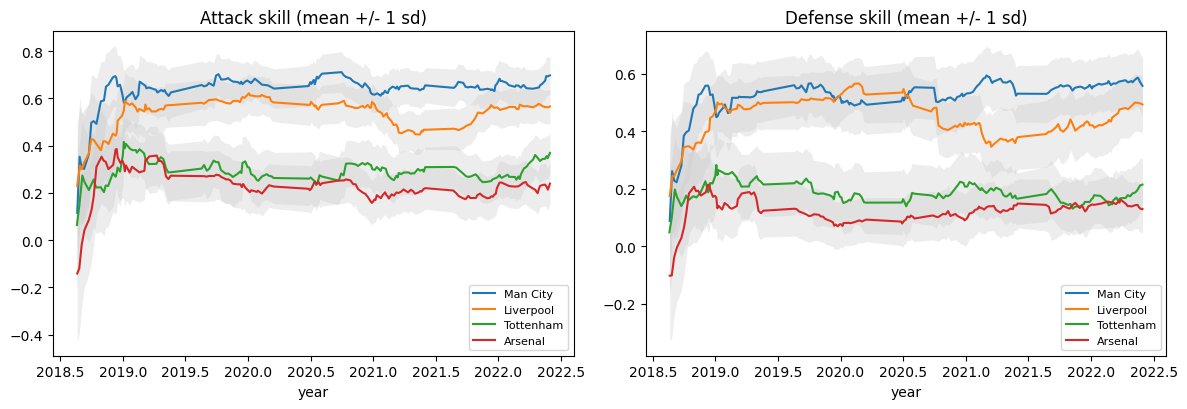

In [8]:
m = bp_model(alpha_f, beta_f, home_f, tau_f, EXKF_init_cov, t0=None)  # our MAP-fitted parameters


def _filter_program():
    with Filter(filter_config=FactorialPFConfig(n_particles=1000, record_filtered_states_mean=True)):
        dsx.sample("skill", m, obs_times=match_times, obs_values=match_goals,
                   obs_factor_indices=match_idx)


_pr = Predictive(_filter_program, num_samples=1)(jax.random.PRNGKey(0))
local = np.asarray(_pr["skill_filtered_local_states_mean"][0])  # (K, 2, 2) -> [slot][att, def]
chol = np.asarray(_pr["skill_filtered_local_states_chol_cov"][0])  # (K, 2, 2, 2)
local_sd = np.sqrt(np.diagonal(chol @ np.swapaxes(chol, -1, -2), axis1=-2, axis2=-1))  # (K, 2, 2) -> [slot][att_sd, def_sd]
idx_np = np.asarray(match_idx); yr = np.asarray(match_times) / 365.25 + 2018.6

def team_traj(team):
    pid = name_to_id[team]; ts, att, dfn, att_sd, dfn_sd = [], [], [], [], []
    for k in range(K):
        for slot in range(2):
            if idx_np[k, slot] == pid:
                ts.append(yr[k]); att.append(local[k, slot, 0]); dfn.append(local[k, slot, 1])
                att_sd.append(local_sd[k, slot, 0]); dfn_sd.append(local_sd[k, slot, 1])
    return (np.array(ts), np.array(att), np.array(dfn), np.array(att_sd), np.array(dfn_sd))

clubs = [c for c in ["Man City", "Liverpool", "Tottenham", "Arsenal"] if c in name_to_id]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for c in clubs:
    ts, att, dfn, att_sd, dfn_sd = team_traj(c)
    axes[0].fill_between(ts, att - att_sd, att + att_sd, color="0.8", alpha=0.35, lw=0)  # +/-1 sd
    axes[1].fill_between(ts, dfn - dfn_sd, dfn + dfn_sd, color="0.8", alpha=0.35, lw=0)
    axes[0].plot(ts, att, lw=1.5, label=c)
    axes[1].plot(ts, dfn, lw=1.5, label=c)
axes[0].set_title("Attack skill (mean +/- 1 sd)"); axes[1].set_title("Defense skill (mean +/- 1 sd)")
for ax in axes:
    ax.set_xlabel("year"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

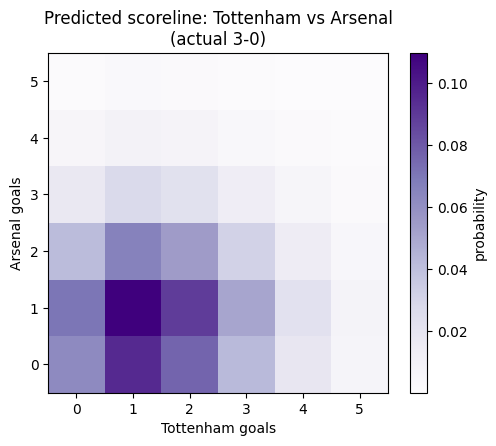

In [9]:
# Predicted scoreline grid for the last fixture between two strong clubs.
pick = None
for k in range(K - 1, -1, -1):
    if id_to_name[int(idx_np[k, 0])] in clubs and id_to_name[int(idx_np[k, 1])] in clubs:
        pick = k; break
grid = np.asarray(bp_out["score_grids"])[pick][:6, :6]
home, away = id_to_name[int(idx_np[pick, 0])], id_to_name[int(idx_np[pick, 1])]
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(grid.T, origin="lower", cmap="Purples")
ax.set_xlabel(f"{home} goals"); ax.set_ylabel(f"{away} goals")
ax.set_title(f"Predicted scoreline: {home} vs {away}\n(actual {int(match_goals[pick,0])}-{int(match_goals[pick,1])})")
plt.colorbar(im, label="probability"); plt.tight_layout(); plt.show()

## 5. Online performance on held-out matches

Using the **self-fitted** bivariate-Poisson parameters, we replay the held-out test period one match at a time. For the most recent matches we plot the model's **expected goals** for and against the home team (its one-step-ahead scoreline forecast) against the **actual** goals, coloured green where the predicted match outcome (win/draw/loss) was correct.


Held-out (test) online W/D/L accuracy: 53.9% over 380 matches


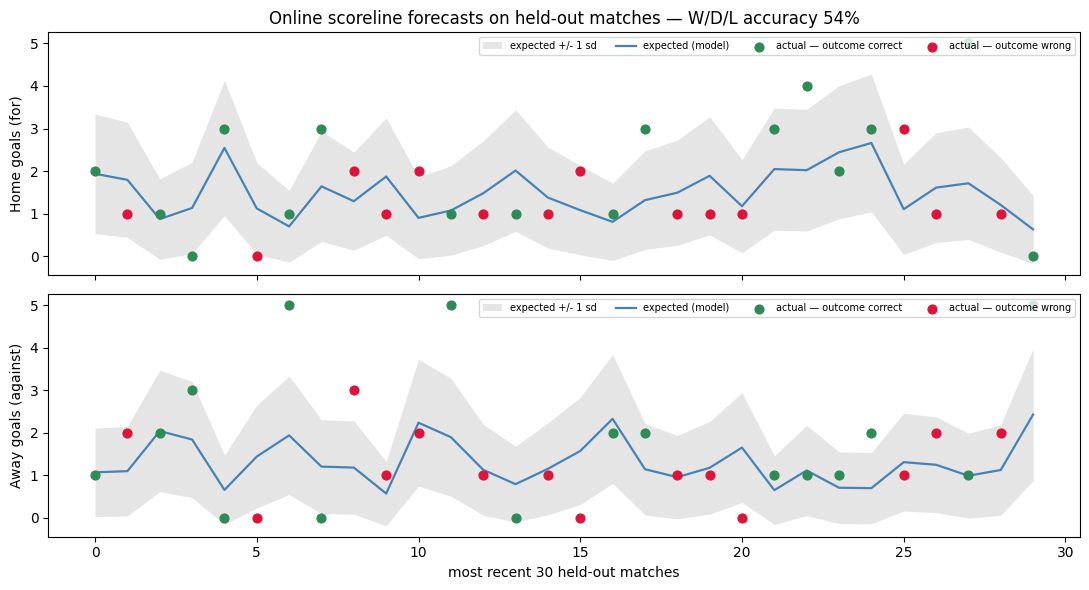

In [10]:
grids = np.asarray(bp_online_out["score_grids"])
gv = np.arange(grids.shape[-1])
ph = grids.sum(2); pa = grids.sum(1)  # marginal home / away goal distributions
exp_home = (ph * gv).sum(1); exp_away = (pa * gv).sum(1)
sd_home = np.sqrt(np.clip((ph * gv**2).sum(1) - exp_home**2, 0, None))
sd_away = np.sqrt(np.clip((pa * gv**2).sum(1) - exp_away**2, 0, None))
wdl_pred = np.asarray(bp_online_out["wdl"]).argmax(1)
actual_out = np.asarray(bp_online_out["outcomes"])
correct = wdl_pred == actual_out
acc = correct[test_start:].mean()
print(f"Held-out (test) online W/D/L accuracy: {acc*100:.1f}% over {K - test_start} matches")

N = 30
sl = slice(K - N, K); x = np.arange(N)
ah = np.asarray(match_goals)[sl, 0]; aa = np.asarray(match_goals)[sl, 1]
cc = correct[sl]
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, exp, sd, act, ttl in [(axes[0], exp_home[sl], sd_home[sl], ah, "Home goals (for)"),
                              (axes[1], exp_away[sl], sd_away[sl], aa, "Away goals (against)")]:
    ax.fill_between(x, exp - sd, exp + sd, color="0.8", alpha=0.5, lw=0, label="expected +/- 1 sd")
    ax.plot(x, exp, color="steelblue", lw=1.6, label="expected (model)")
    ax.scatter(x[cc], act[cc], c="seagreen", s=40, zorder=3, label="actual — outcome correct")
    ax.scatter(x[~cc], act[~cc], c="crimson", s=40, zorder=3, label="actual — outcome wrong")
    ax.set_ylabel(ttl); ax.legend(fontsize=7, ncol=4, loc="upper right")
axes[1].set_xlabel(f"most recent {N} held-out matches")
axes[0].set_title(f"Online scoreline forecasts on held-out matches — W/D/L accuracy {acc*100:.0f}%")
plt.tight_layout(); plt.show()